# Auditar dentro de un nodo

`gradient_audit()` a nivel de grafo trata cada filtro como opaco: un
registro por nodo y paso. Con `inside=` los hooks entran en el modelo
del nodo y cada submódulo audita bajo un id jerárquico
(`encoder/<ruta.del.módulo>`): mismos registros, flags, persistencia y
figuras. Aquí lo vemos cazar un *vanishing gradient* de libro.

In [1]:
import warnings

import plotly.io as pio
import torch
import torch.nn as nn

import soma

# PNG estático para las figuras (comenta para interactivo) y silencio
# del aviso benigno de PyTorch sobre backward hooks.
pio.renderers.default = "png"
pio.renderers["png"].scale = 2      # nítido en pantallas retina
pio.renderers["png"].width = 950
warnings.filterwarnings("ignore", message="Full backward hook is firing")
from soma import AuditScope, DifferentiableFilter, Graph


class DeepEncoder(DifferentiableFilter):
    _cache_version = "nb08-deep-v1"

    def __init__(self, layers=12):
        super().__init__(layers=layers)

    def build_module(self, input_shape):
        mods = []
        for _ in range(self.layers):
            lin = nn.Linear(input_shape[-1], input_shape[-1])
            with torch.no_grad():
                lin.weight.mul_(0.35)  # init contractiva: gradientes se apagan
            mods += [lin, nn.Tanh()]
        return nn.Sequential(*mods)

    def output_shape(self, input_shape):
        return input_shape


torch.manual_seed(0)
g = Graph()
g.node("encoder", DeepEncoder())
x, y = torch.randn(64, 8), torch.randn(64, 8)
g.materialize(x)
g.train()
g.make_optimizer(torch.optim.Adam, lr=1e-3)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

## `inside=True`: cero configuración

Autoselección: los hijos directos con parámetros (los wrappers de un
solo hijo se descienden). El nodo raíz sigue auditándose bajo su id
plano. Alternativas, todas equivalentes por dentro:

```python
g.gradient_audit(inside={"encoder": 2})            # int = profundidad
g.gradient_audit(inside={"encoder": ["0", "4.*"]}) # patrones fnmatch
g.gradient_audit(inside={"encoder": AuditScope(depth=3, sample_every=10)})

class DeepEncoder(DifferentiableFilter):
    _audit_scope = "auto"   # declarado donde vive el modelo
```

Precedencia: `inside[...]` > `_audit_scope` de la clase > auto.

In [2]:
with g.track_run("nb08-inside", tags=["demo"]) as run:
    with g.gradient_audit(inside=True) as audit:
        for epoch in range(4):
            with g.context() as ctx:
                g.zero_grad()
                out, _ = g.forward(x)
                g.backward(ctx, nn.functional.mse_loss(out, y))
            g.step(ctx)

print(audit.report().pretty())

                  filter   steps      act|μ|       act σ      |out∂|        |θ∂|         |θ|         ∂/θ                     flags
----------------------------------------------------------------------------------------------------------------------------------
                 encoder       4   2.176e-01   2.119e-01   9.568e-02   2.778e-01   2.845e+00   9.765e-02                   HEALTHY
               encoder/0       4   2.166e-01   2.624e-01   1.931e-09   1.120e-08   7.447e-01   1.503e-08                 VANISHING
               encoder/2       4   1.993e-01   2.315e-01   1.322e-08   4.892e-08   8.452e-01   5.787e-08                 VANISHING
               encoder/4       4   1.770e-01   2.026e-01   8.374e-08   3.280e-07   8.164e-01   4.017e-07                   HEALTHY
               encoder/6       4   1.876e-01   2.247e-01   4.840e-07   1.822e-06   8.897e-01   2.048e-06                   HEALTHY
               encoder/8       4   1.320e-01   1.559e-01   2.361e-06   9.146e-06   

## El flujo de gradientes, capa a capa

El gráfico clásico: submódulos en orden de ejecución real en x, `|∂|`
en escala log en y. Un *vanishing* se lee como escalera que cae hacia
la entrada — aquí, varios órdenes de magnitud.

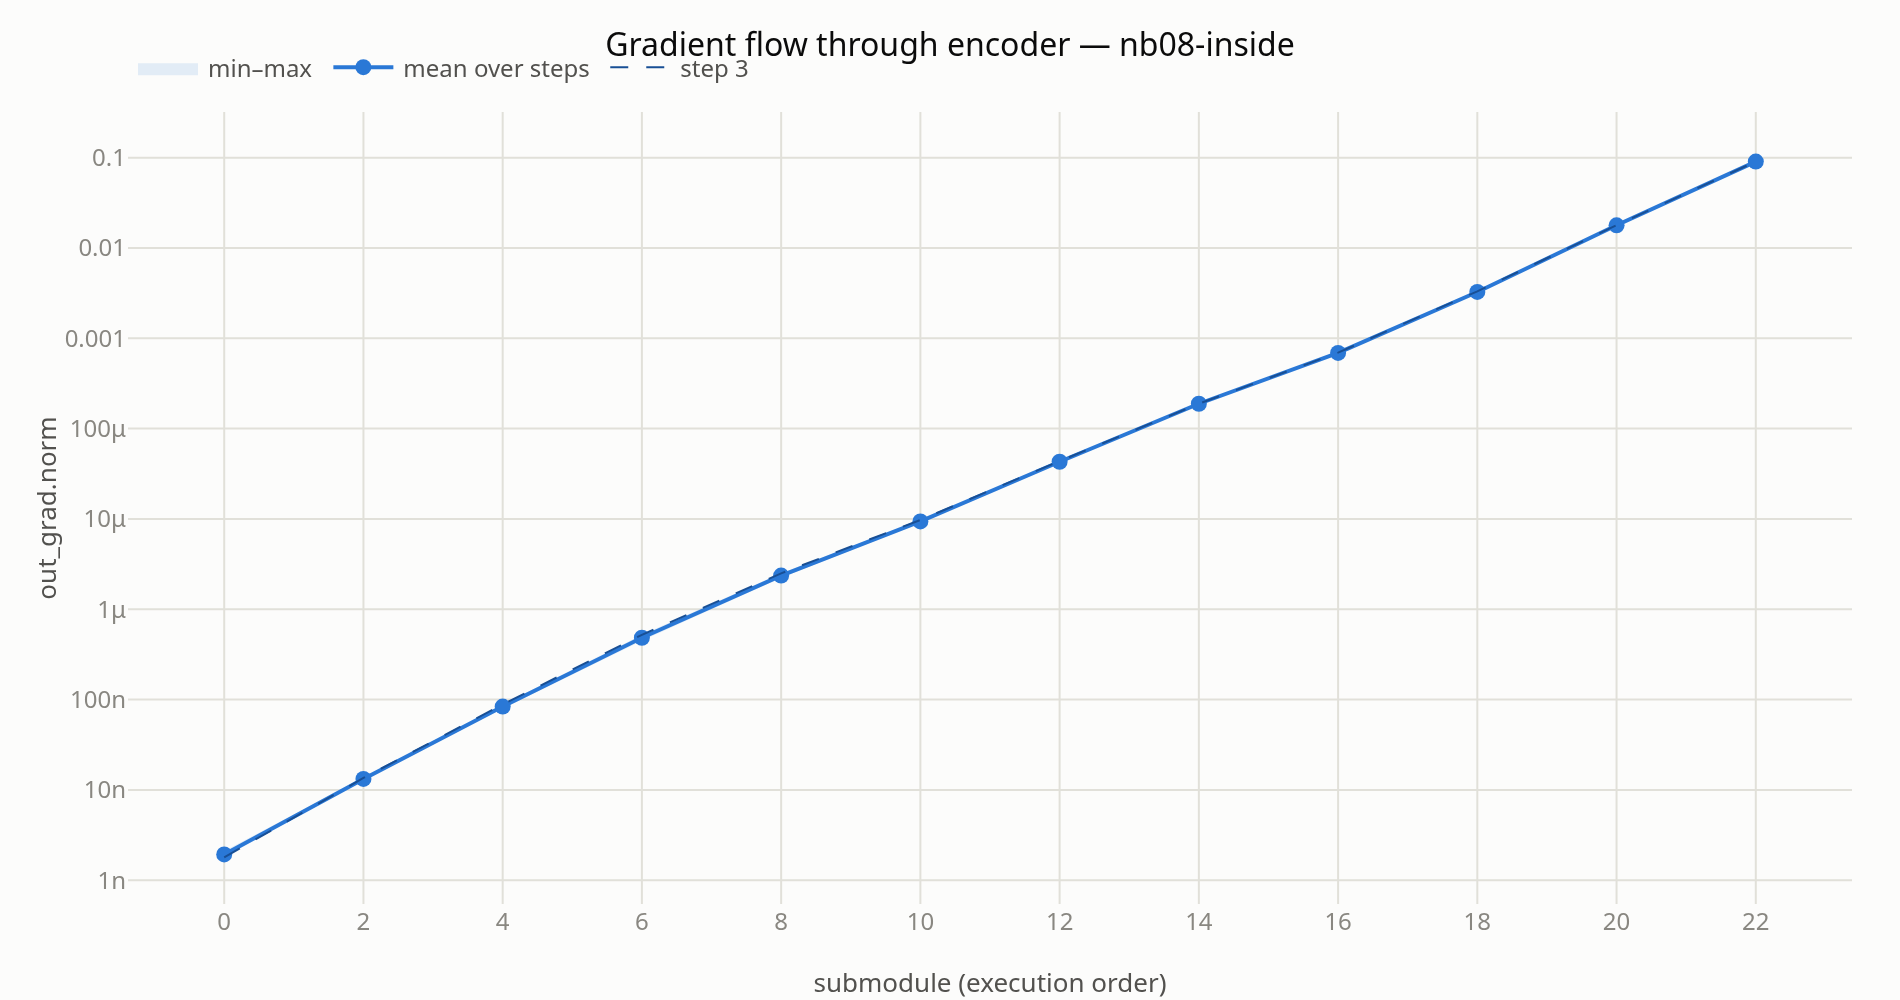

In [3]:
view = soma.RunView(run.dir)
view.plot_module_flow("encoder")

## La arquitectura interna, anotada

El árbol de submódulos se persiste en `diagnostics/modules/encoder.json`
(mismo esquema Graph que `graph.json`) y se renderiza con el mismo
mecanismo de overlay: parámetros, `|∂|` medio y flags por capa.

In [4]:
print(view.to_mermaid(node="encoder"))

graph LR
    n_0["0<br/>⚠ VANISHING · 72 θ · |∂| 1.93e-09"]
    n_2["2<br/>⚠ VANISHING · 72 θ · |∂| 1.32e-08"]
    n_4["4<br/>72 θ · |∂| 8.37e-08"]
    n_6["6<br/>72 θ · |∂| 4.84e-07"]
    n_8["8<br/>72 θ · |∂| 2.36e-06"]
    n_10["10<br/>72 θ · |∂| 9.40e-06"]
    n_12["12<br/>72 θ · |∂| 4.30e-05"]
    n_14["14<br/>72 θ · |∂| 1.89e-04"]
    n_16["16<br/>72 θ · |∂| 6.89e-04"]
    n_18["18<br/>72 θ · |∂| 3.26e-03"]
    n_20["20<br/>72 θ · |∂| 1.78e-02"]
    n_22["22<br/>72 θ · |∂| 9.05e-02"]
    n_0 --> n_2
    n_2 --> n_4
    n_4 --> n_6
    n_6 --> n_8
    n_8 --> n_10
    n_10 --> n_12
    n_12 --> n_14
    n_14 --> n_16
    n_16 --> n_18
    n_18 --> n_20
    n_20 --> n_22
    classDef soma_flagged fill:#fff3e0,stroke:#ef6c00,stroke-width:3px,color:#e65100;
    class n_0 soma_flagged
    class n_2 soma_flagged



## Flags con rollup

Cada capa flaggeada emite su `HealthFlag` propio **y** el nodo padre
recibe uno agregado por familia cuyo detalle nombra las capas — el DAG
externo marca el nodo, las vistas internas señalan la capa exacta.

In [5]:
parent = [f for f in view.health_flags() if f["node_id"] == "encoder"]
children = [f for f in view.health_flags() if f["node_id"].startswith("encoder/")]
print(f"{len(children)} flags de capa; rollup en el padre:")
[f["detail"] for f in parent]

2 flags de capa; rollup en el padre:


['in: 0, 2']

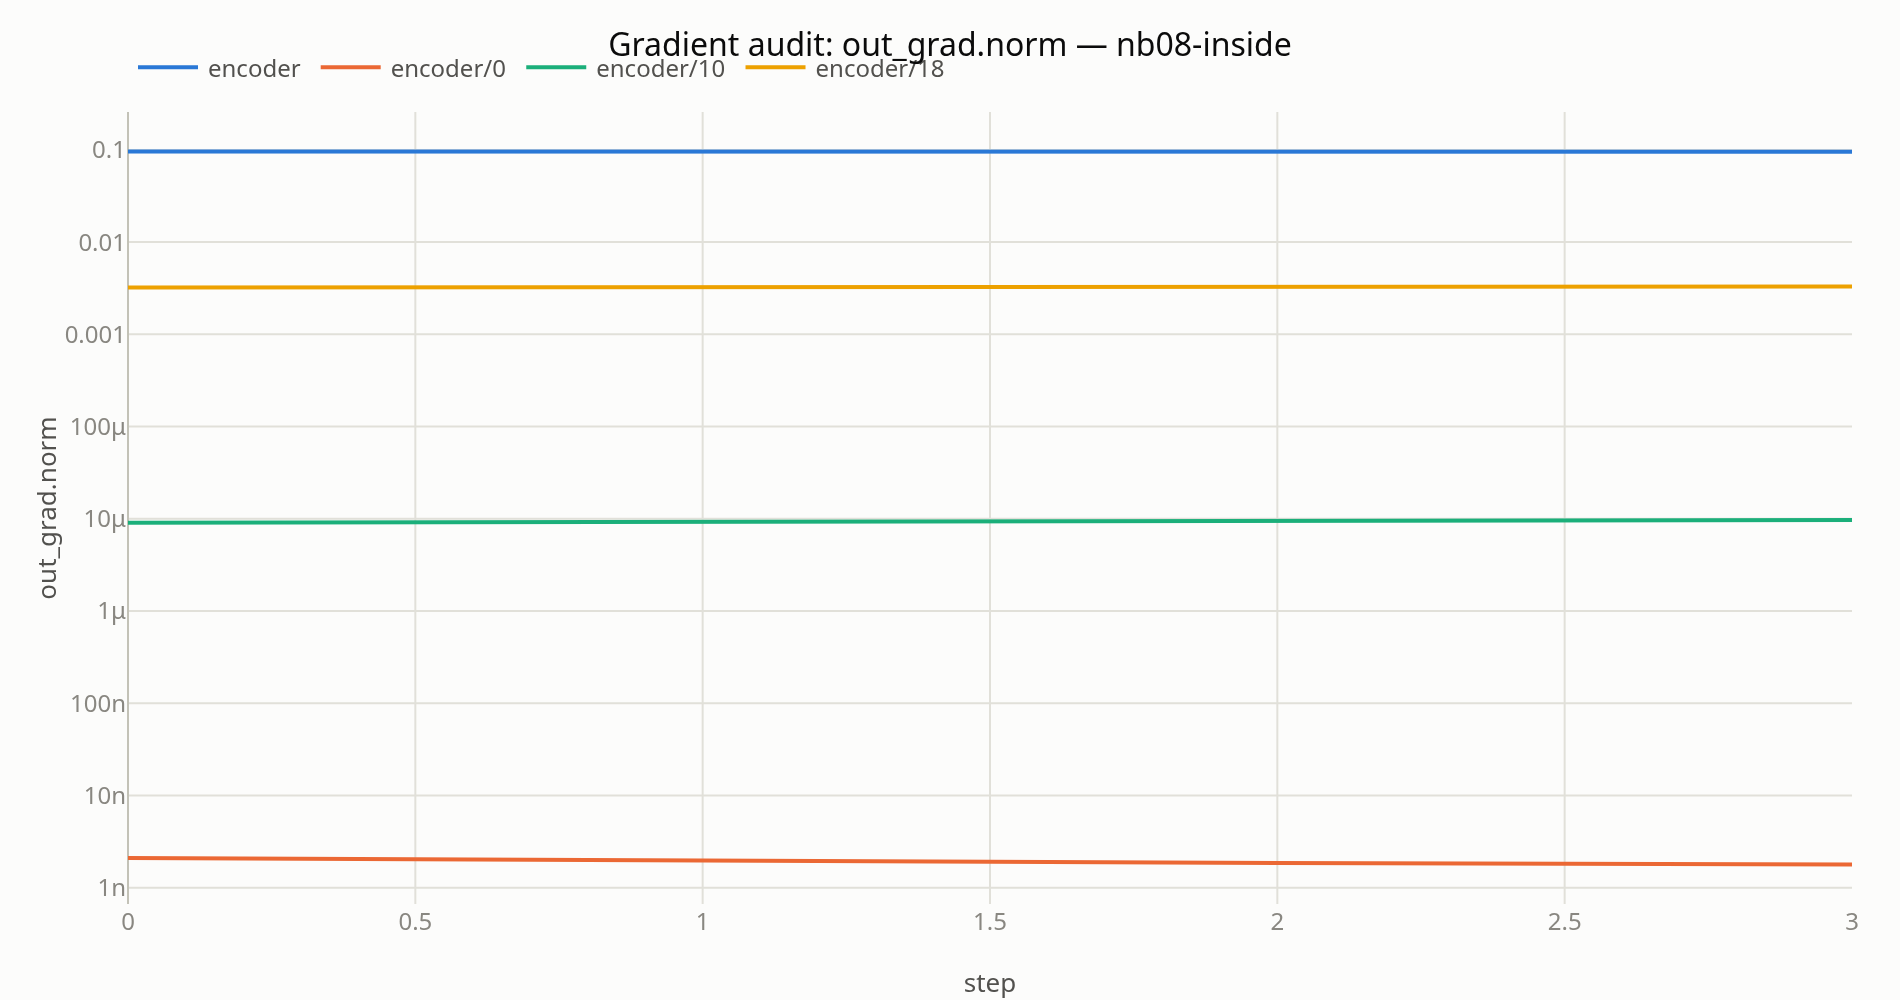

In [6]:
# Series temporales por capa (por defecto plot_audit solo muestra
# raíces; node="encoder" las traería todas y avisaría del límite de 8).
# Comparamos entrada / medio / salida:
view.plot_audit(
    filters=["encoder", "encoder/0", "encoder/10", "encoder/18"],
    metric="out_grad.norm",
)

`soma report <run_id>` incluye todo esto en la sección **Module flow**
del informe. Para modelos grandes: `AuditScope(sample_every=N)` muestrea
los submódulos cada N pasos (el raíz siempre registra), y `max_modules`
limita la selección avisando — nunca en silencio.